# 🗑️ EDA — Waste Classifier ML


---

| Bloque | Pregunta que responde |
|--------|----------------------|
| 0 | Setup | Rutas, semilla, clases |
| 1 | ¿Cuánto desbalance real hay? |
| 2 | ¿Las imágenes tienen calidad y variedad? |
| 3 | ¿Qué resoluciones hay? |
| 4 | ¿Usamos normalización ImageNet o propia? |
| 5 | Resumen JSON|

---
## 📚 Bloque 0 — Setup e imports

Cargamos las librerías, montamos el Drive y definimos todas las rutas y constantes del proyecto.  


In [ ]:
import os
import sys
import json
import random
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image
from tqdm import tqdm

# ── Detectar entorno ──
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT_ROOT = Path('/content/drive/MyDrive/waste_classifier')
else:
    PROJECT_ROOT = Path().resolve().parent.parent

# ── Rutas del proyecto ──
RAW   = PROJECT_ROOT / 'data' / 'raw'
SPLIT = PROJECT_ROOT / 'data' / 'splits'
LOGS  = PROJECT_ROOT / 'logs'
LOGS.mkdir(parents=True, exist_ok=True)

# ── Constantes del proyecto ──
CLASSES = ['vidrio', 'plastico', 'metal', 'papel', 'organico', 'carton', 'no_reciclable']
COLORS  = ['#378ADD', '#1D9E75', '#EF9F27', '#D4537E', '#7F77DD', '#5DCAA5', '#E24B4A']

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# ── Verificación de directorios ──
print('=' * 50)
print('  WASTE CLASSIFIER — EDA Mínimo')
print('=' * 50)
print(f'Entorno  : {"Google Colab" if IN_COLAB else "Local"}')
print(f'PROJECT_ROOT  : {PROJECT_ROOT}')
print(f'RAW      : {RAW}  → existe: {RAW.exists()}')
print(f'SPLIT    : {SPLIT} → existe: {SPLIT.exists()}')
print(f'LOGS     : {LOGS}  → existe: {LOGS.exists()}')
print(f'Clases   : {CLASSES}')

Mounted at /content/drive
hola
  WASTE CLASSIFIER — EDA Mínimo
Entorno  : Google Colab
BASE     : /content/drive/MyDrive/waste_classifier
RAW      : /content/drive/MyDrive/waste_classifier/data/raw  → existe: True
SPLIT    : /content/drive/MyDrive/waste_classifier/data/splits → existe: True
LOGS     : /content/drive/MyDrive/waste_classifier/logs  → existe: True
Clases   : ['vidrio', 'plastico', 'metal', 'papel', 'organico', 'carton', 'no_reciclable']


---
## 🔗 Bloque 1 — Distribución de clases

> ¿Cuánto desbalance real tenemos y qué `class_weight` necesitamos?  


Train :  7644 imágenes
Val   :  1639 imágenes
Test  :  1639 imágenes  ← SELLADO, no tocar
Total : 10922 imágenes

Clase            Train   Val  Test  Total  Bar
----------------------------------------------------------------------
vidrio            1710   367   367   2444  ██████████████████████████████████████████
plastico          1252   268   268   1788  ███████████████████████████████
metal             1090   234   234   1558  ███████████████████████████
papel             1085   232   233   1550  ███████████████████████████
organico           977   210   209   1396  ████████████████████████
carton             946   203   203   1352  ███████████████████████
no_reciclable      584   125   125    834  ██████████████

⚠️  Ratio max/min (train): 2.93x
   → Desbalance moderado — class_weight recomendado

📊 class_weight calculados ("balanced"):
  no_reciclable   1.8699  ██████████████████████
  carton          1.1543  █████████████
  organico        1.1177  █████████████
  papel         

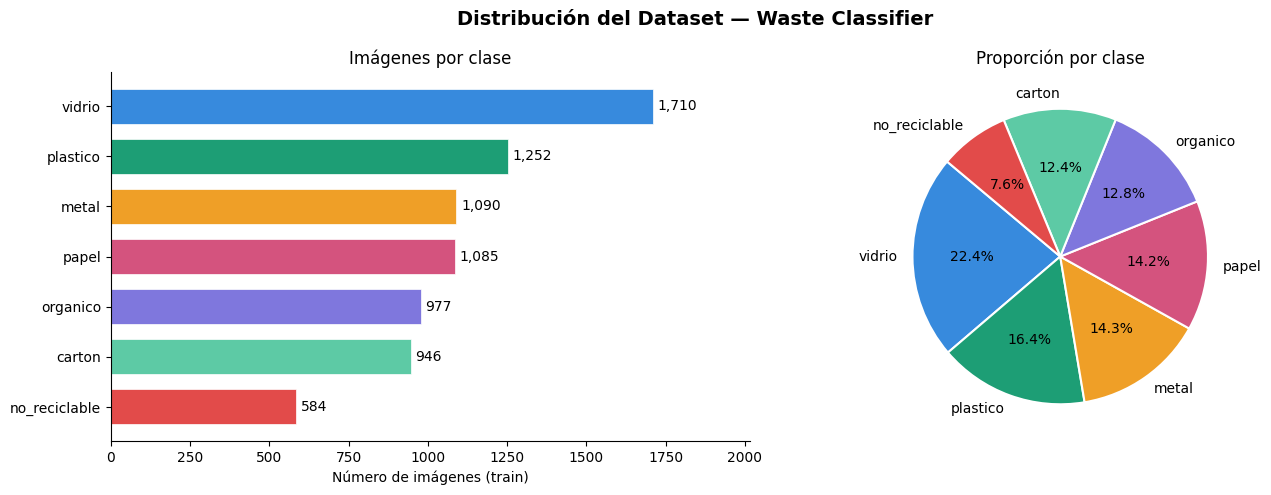

✅ eda_class_distribution.png guardado


In [ ]:

from sklearn.utils.class_weight import compute_class_weight

# ── Cargar splits ─────────────────────────────────────────────
train_df = pd.read_csv(SPLIT / 'train.csv')
val_df   = pd.read_csv(SPLIT / 'val.csv')
test_df  = pd.read_csv(SPLIT / 'test.csv')

print(f'Train : {len(train_df):>5} imágenes')
print(f'Val   : {len(val_df):>5} imágenes')
print(f'Test  : {len(test_df):>5} imágenes  ← SELLADO, no tocar')
print(f'Total : {len(train_df)+len(val_df)+len(test_df):>5} imágenes')

# ── Conteo por clase en train ──
LABEL_COL = 'label'

class_counts = train_df[LABEL_COL].value_counts().reindex(CLASSES)
total   = class_counts.sum()
ratio   = class_counts.max() / class_counts.min()

print(f'\n{"Clase":<15} {"Train":>6} {"Val":>5} {"Test":>5} {"Total":>6}  Bar')
print('-' * 70)
for cls in CLASSES:
    tr = train_df[LABEL_COL].value_counts().get(cls, 0)
    va = val_df[LABEL_COL].value_counts().get(cls, 0)
    te = test_df[LABEL_COL].value_counts().get(cls, 0)
    bar = '█' * int(tr / 40)
    print(f'{cls:<15} {tr:>6} {va:>5} {te:>5} {tr+va+te:>6}  {bar}')

print(f'\n⚠️  Ratio max/min (train): {ratio:.2f}x')
if ratio > 3:
    print('   → Desbalance alto — class_weight NECESARIO + augmentation asimétrico')
elif ratio > 1.5:
    print('   → Desbalance moderado — class_weight recomendado')
else:
    print('   → Dataset bien balanceado ✅')

# ── Calcular class_weight ──
y_train = train_df[LABEL_COL].values
weights = compute_class_weight('balanced', classes=np.array(CLASSES), y=y_train)
class_weight_dict = {cls: float(round(w, 4)) for cls, w in zip(CLASSES, weights)}

print(f'\n📊 class_weight calculados ("balanced"):')
for cls, w in sorted(class_weight_dict.items(), key=lambda x: -x[1]):
    bar = '█' * int(w * 12)
    print(f'  {cls:<15} {w:.4f}  {bar}')

# ── Guardar class_weights ──
with open(LOGS / 'class_weights.json', 'w') as f:
    json.dump(class_weight_dict, f, indent=2, ensure_ascii=False)
print('\n✅ class_weights.json guardado en logs/')

# ── Plot ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribución del Dataset — Waste Classifier', fontsize=14, fontweight='bold')

counts_sorted  = class_counts.sort_values()
colors_sorted  = [COLORS[CLASSES.index(c)] for c in counts_sorted.index]

# Barras horizontales
bars = axes[0].barh(counts_sorted.index, counts_sorted.values,
                    color=colors_sorted, height=0.7, edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, counts_sorted.values):
    axes[0].text(val + 15, bar.get_y() + bar.get_height()/2,
                    f'{val:,}', va='center', fontsize=10)
axes[0].set_xlabel('Número de imágenes (train)')
axes[0].set_title('Imágenes por clase')
axes[0].set_xlim(0, counts_sorted.max() * 1.18)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Pie
axes[1].pie(class_counts.values, labels=class_counts.index,
            colors=COLORS, autopct='%1.1f%%', startangle=140,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('Proporción por clase')

plt.tight_layout()
plt.savefig(LOGS / 'eda_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ eda_class_distribution.png guardado')

---
## 🎞️ Bloque 2 — Grid visual

¿Las imágenes tienen la calidad y variedad esperada por clase?  

Queremos detectar anomalías visuales (imágenes demasiado pequeñas, corruptas, fuera de clase).  


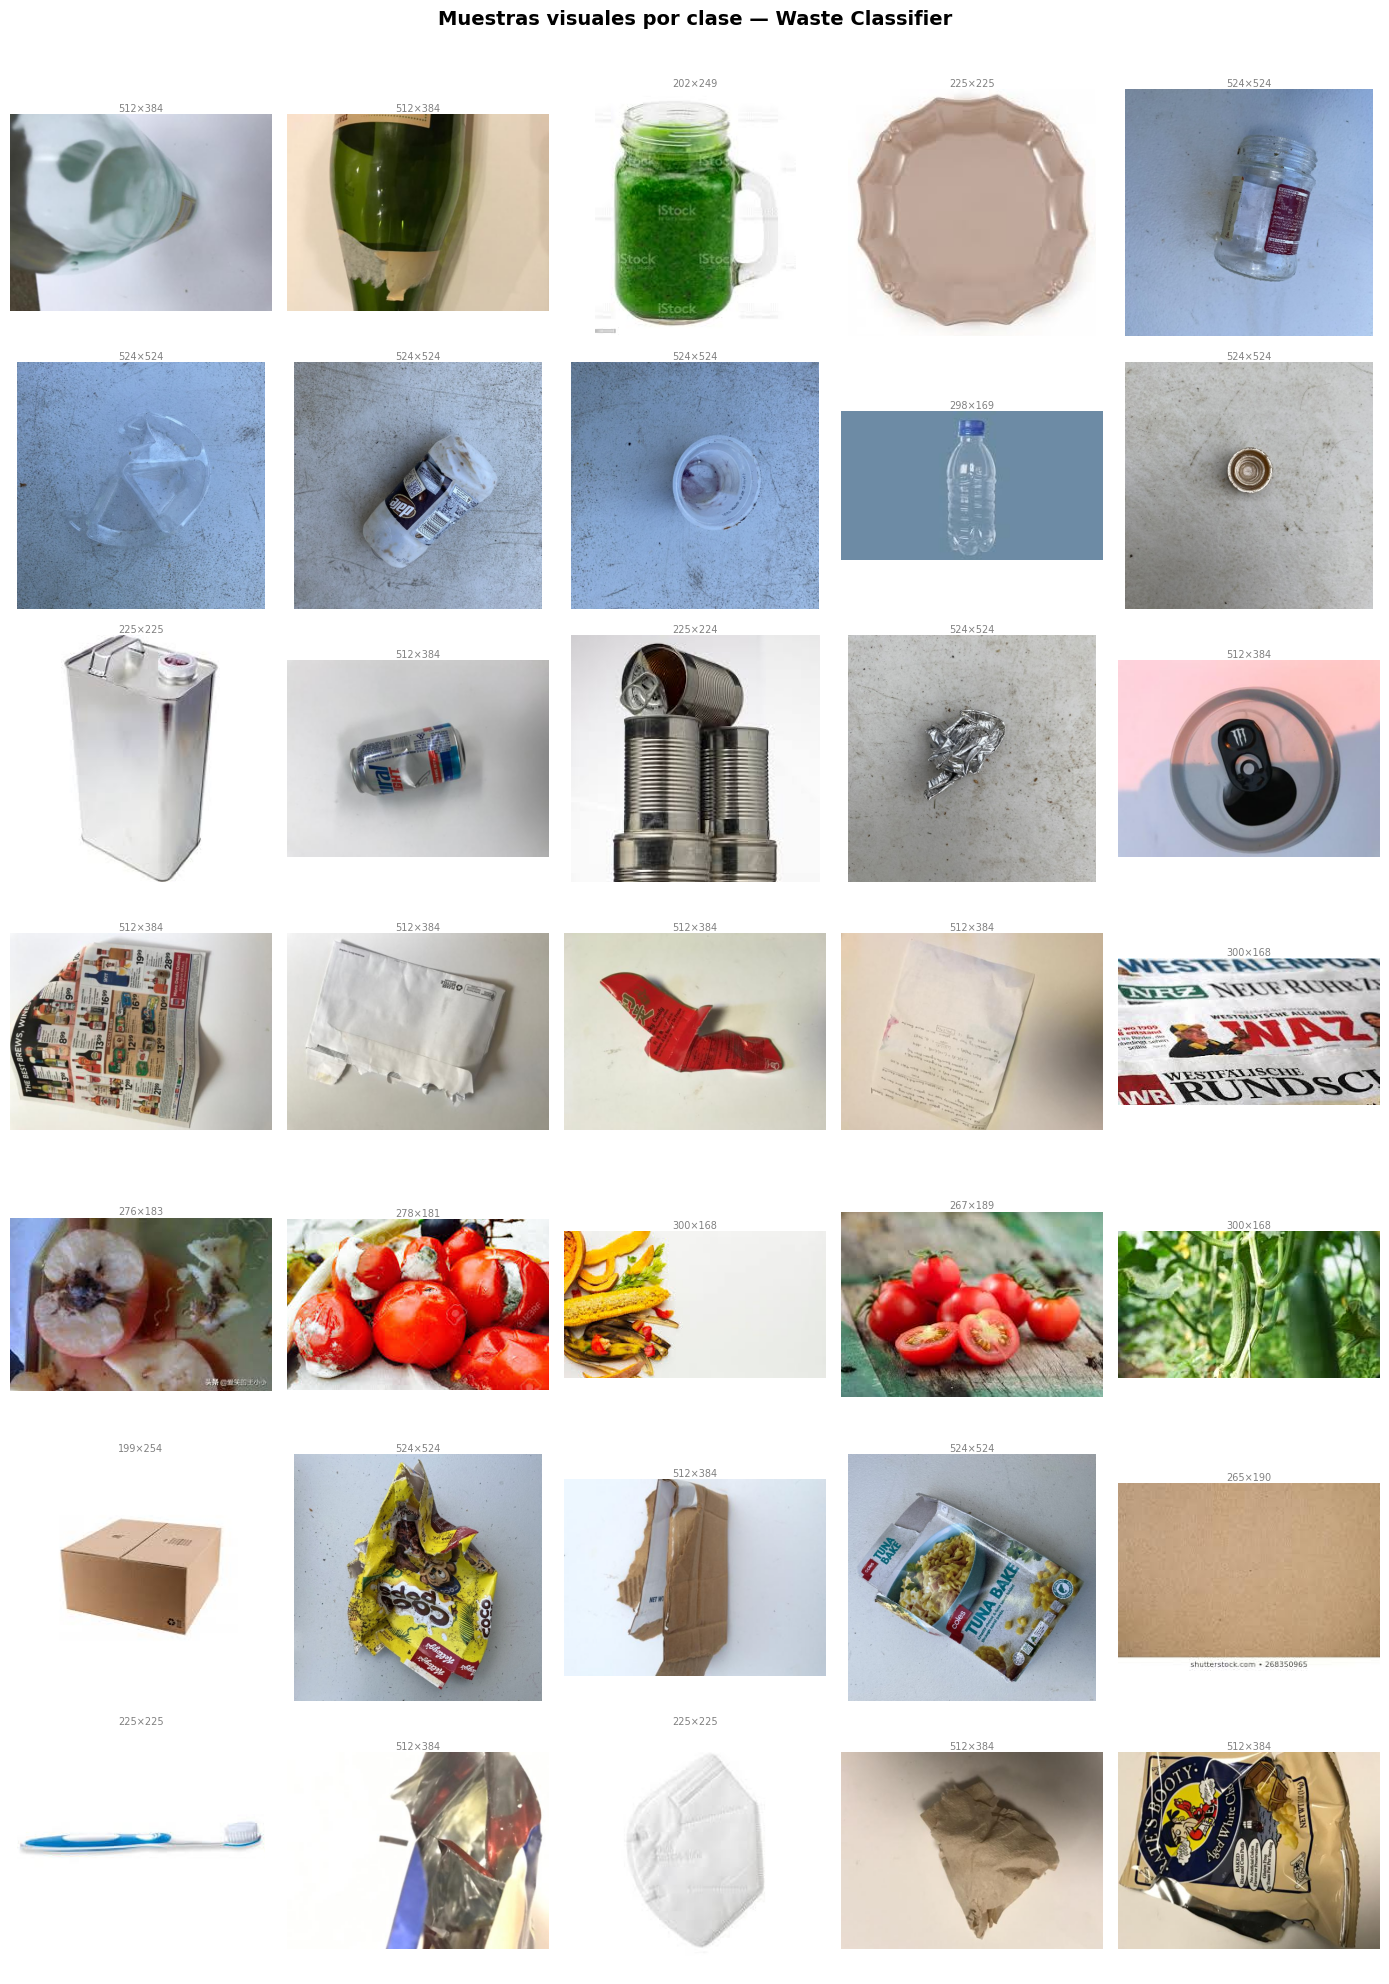


✅ Grid generado — 7 clases × 5 muestras
✅ Sin anomalías visuales detectadas
✅ eda_visual_grid.png guardado


In [ ]:
N_SAMPLES = 5  # columnas por clase
IMG_EXTS  = ('*.jpg', '*.jpeg', '*.png', '*.JPG', '*.JPEG', '*.PNG')

def get_images(cls_dir):
    imgs = []
    for ext in IMG_EXTS:
        imgs.extend(list(cls_dir.glob(ext)))
    return imgs

fig, axes = plt.subplots(len(CLASSES), N_SAMPLES,
                          figsize=(N_SAMPLES * 2.8, len(CLASSES) * 2.8))
fig.suptitle('Muestras visuales por clase — Waste Classifier',
                fontsize=14, fontweight='bold', y=1.01)

anomalies = []

for row, cls in enumerate(CLASSES):
    cls_dir = RAW / cls

    if not cls_dir.exists():
        print(f'⚠️  Carpeta no encontrada: {cls_dir}')
        for col in range(N_SAMPLES):
            axes[row][col].axis('off')
        continue

    all_imgs = get_images(cls_dir)
    samples  = random.sample(all_imgs, min(N_SAMPLES, len(all_imgs)))

    for col in range(N_SAMPLES):
        ax = axes[row][col]
        ax.axis('off')

        if col >= len(samples):
            ax.set_facecolor('#f5f5f5')
            continue

        img_path = samples[col]
        try:
            img = Image.open(img_path).convert('RGB')
            w, h = img.size
            ax.imshow(img)
            ax.set_title(f'{w}×{h}', fontsize=7, color='gray', pad=2)

            # Detectar imagen sospechosamente pequeña
            if w < 64 or h < 64:
                ax.set_title(f'⚠️ {w}×{h}', fontsize=7, color='red', pad=2)
                for spine in ax.spines.values():
                    spine.set_edgecolor('red')
                    spine.set_linewidth(2)
                anomalies.append({'clase': cls, 'ruta': str(img_path), 'size': f'{w}×{h}'})

        except Exception as e:
            ax.set_facecolor('#ffeeee')
            ax.text(0.5, 0.5, f'ERROR\n{type(e).__name__}',
                    ha='center', va='center', color='red',
                    fontsize=7, transform=ax.transAxes)
            anomalies.append({'clase': cls, 'ruta': str(img_path), 'size': 'ERROR'})

        if col == 0:
            ax.set_ylabel(cls, rotation=0, labelpad=60,
                            fontsize=11, fontweight='bold', va='center')

plt.tight_layout()
plt.savefig(LOGS / 'eda_visual_grid.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n✅ Grid generado — {len(CLASSES)} clases × {N_SAMPLES} muestras')
if anomalies:
    print(f'⚠️  {len(anomalies)} anomalías detectadas:')
    for a in anomalies[:10]:
        print(f'   [{a["clase"]}] {a["size"]}  → {a["ruta"]}')
else:
    print('✅ Sin anomalías visuales detectadas')

print('✅ eda_visual_grid.png guardado')

---
## 📐 Bloque 3 — Análisis de resoluciones

¿Hay resoluciones inconsistentes que afecten al resize 224×224?

Analizando resoluciones (muestra por clase)...



📐 Resoluciones (muestra total: 1400 imágenes):
  Ancho   min: 114px  max: 524px  mediana: 512px  media: 392px
  Alto    min: 107px max: 524px mediana: 384px media: 349px

  Imágenes con algún lado < 224px : 464 (33.1%)
  Imágenes con algún lado < 96px        : 0 (0.0%)


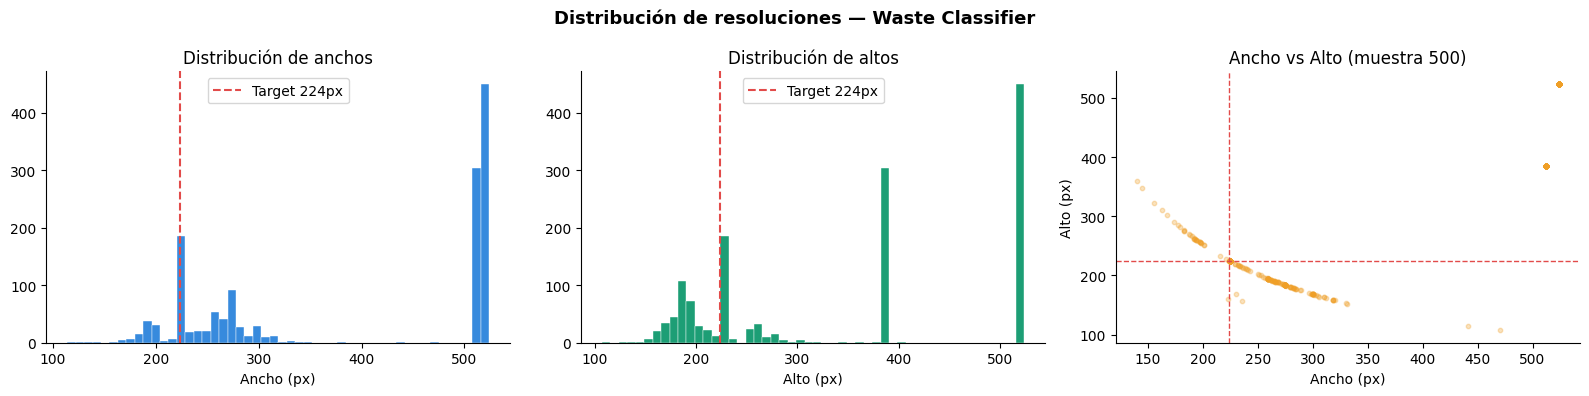


→ Decisión: resize bilinear a 224×224 cubre todos los casos
  EfficientNetB0 incluye preprocess_input — no se pierde información significativa
✅ eda_resolutions.png guardado


In [ ]:

TARGET_SIZE  = (224, 224)
SAMPLE_N     = 200   # imágenes por clase (muestra)

resolution_data = {cls: [] for cls in CLASSES}

print('Analizando resoluciones...')
for cls in CLASSES:
    cls_dir  = RAW / cls
    if not cls_dir.exists():
        print(f'  ⚠️  {cls} — carpeta no encontrada')
        continue

    all_imgs = get_images(cls_dir)
    sample   = random.sample(all_imgs, min(SAMPLE_N, len(all_imgs)))

    for p in tqdm(sample, desc=f'  {cls:<15}', leave=False):
        try:
            with Image.open(p) as img:
                resolution_data[cls].append(img.size)   # (W, H)
        except:
            pass

# ── Estadísticas globales ──
all_res = [r for cls_res in resolution_data.values() for r in cls_res]
widths  = [r[0] for r in all_res]
heights = [r[1] for r in all_res]

print(f'\n📐 Resoluciones (muestra total: {len(all_res)} imágenes):')
print(f'  Ancho   min: {min(widths)}px  max: {max(widths)}px  mediana: {int(np.median(widths))}px  media: {int(np.mean(widths))}px')
print(f'  Alto    min: {min(heights)}px max: {max(heights)}px mediana: {int(np.median(heights))}px media: {int(np.mean(heights))}px')

# Porcentaje de imágenes más pequeñas que el target
smaller = sum(1 for w, h in all_res if w < TARGET_SIZE[0] or h < TARGET_SIZE[1])
print(f'\n  Imágenes con algún lado < {TARGET_SIZE[0]}px : {smaller} ({smaller/len(all_res)*100:.1f}%)')
tiny    = sum(1 for w, h in all_res if w < 96 or h < 96)
print(f'  Imágenes con algún lado < 96px        : {tiny} ({tiny/len(all_res)*100:.1f}%)')

# ── Plot resoluciones ──
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Distribución de resoluciones — Waste Classifier', fontsize=13, fontweight='bold')

# Histograma anchos
axes[0].hist(widths, bins=50, color='#378ADD', edgecolor='white', linewidth=0.3)
axes[0].axvline(TARGET_SIZE[0], color='#E24B4A', linestyle='--', linewidth=1.5,
                label=f'Target {TARGET_SIZE[0]}px')
axes[0].set_xlabel('Ancho (px)')
axes[0].set_title('Distribución de anchos')
axes[0].legend()
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Histograma altos
axes[1].hist(heights, bins=50, color='#1D9E75', edgecolor='white', linewidth=0.3)
axes[1].axvline(TARGET_SIZE[1], color='#E24B4A', linestyle='--', linewidth=1.5,
                label=f'Target {TARGET_SIZE[1]}px')
axes[1].set_xlabel('Alto (px)')
axes[1].set_title('Distribución de altos')
axes[1].legend()
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

# Scatter ancho vs alto
sample_scatter = random.sample(all_res, min(500, len(all_res)))
ws = [r[0] for r in sample_scatter]
hs = [r[1] for r in sample_scatter]
axes[2].scatter(ws, hs, alpha=0.3, s=10, color='#EF9F27')
axes[2].axvline(TARGET_SIZE[0], color='#E24B4A', linestyle='--', linewidth=1)
axes[2].axhline(TARGET_SIZE[1], color='#E24B4A', linestyle='--', linewidth=1)
axes[2].set_xlabel('Ancho (px)')
axes[2].set_ylabel('Alto (px)')
axes[2].set_title('Ancho vs Alto (muestra 500)')
axes[2].spines['top'].set_visible(False)
axes[2].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(LOGS / 'eda_resolutions.png', dpi=150, bbox_inches='tight')
plt.show()

print('✅ eda_resolutions.png guardado')

---
## 🎨 Bloque 4 — Estadísticas de color

¿Usamos la normalización estándar de ImageNet o calculamos mean/std propios?  

Calculando estadísticas de color...


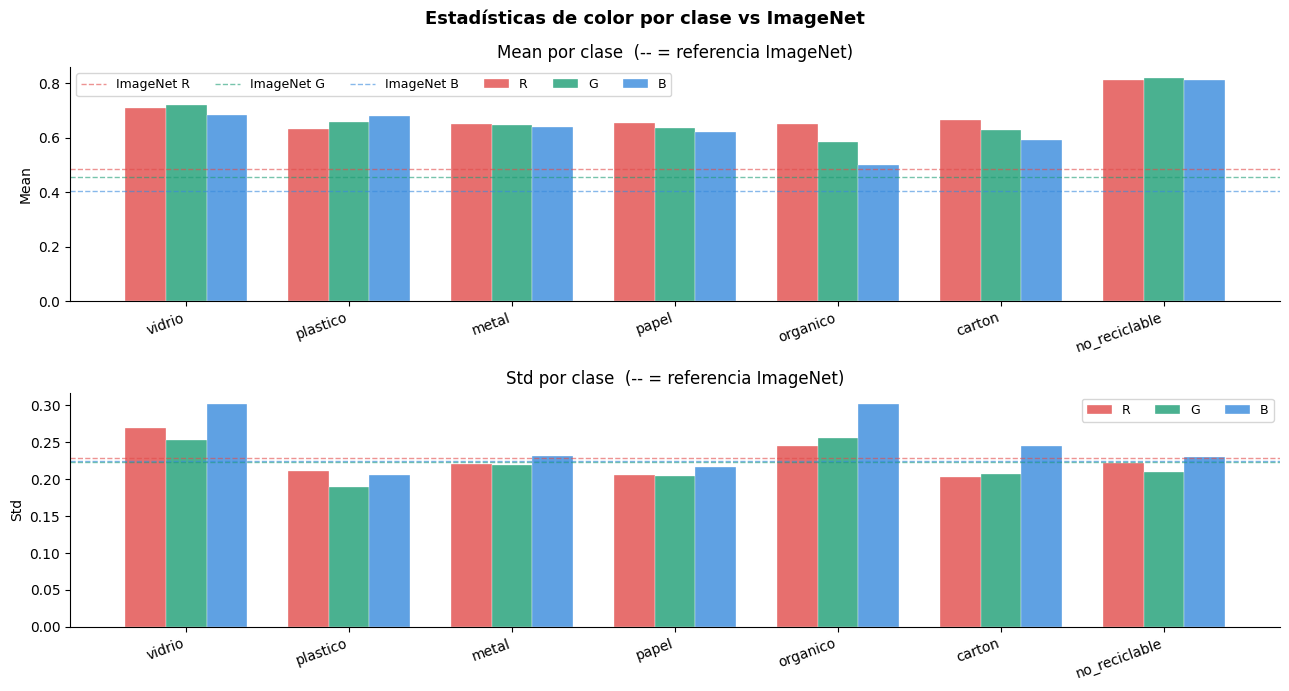


📊 Desviación media respecto a ImageNet mean (por clase):
  📌 vidrio          Δ = 0.2559  █████████████████████████
  📌 plastico        Δ = 0.2078  ████████████████████
  📌 metal           Δ = 0.1980  ███████████████████
  📌 papel           Δ = 0.1879  ██████████████████
  📌 organico        Δ = 0.1285  ████████████
  📌 carton          Δ = 0.1792  █████████████████
  📌 no_reciclable   Δ = 0.3654  ████████████████████████████████████

───────────────────────────────────────────────────────
INTERPRETACIÓN DEL Δ
───────────────────────────────────────────────────────
  Δ máximo : 0.3654 — dataset más brillante que ImageNet
  Causa    : fondos blancos/claros en fotos de residuos
  Esperado : ✅ coherente con el tipo de dataset

DECISIÓN DE NORMALIZACIÓN
───────────────────────────────────────────────────────
  → EfficientNetB0: usar preprocess_input de la librería
    from tensorflow.keras.applications.efficientnet import preprocess_input
    Escala a [-1, 1] — sus pesos fueron entrenados co

In [ ]:
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406])   # RGB
IMAGENET_STD  = np.array([0.229, 0.224, 0.225])
COLOR_SAMPLE  = 150   # imágenes por clase
THUMB_SIZE    = 64    # resolución de muestra para calcular stats (rápido)

color_stats = {}
print('Calculando estadísticas de color...')

for cls in CLASSES:
    cls_dir  = RAW / cls
    if not cls_dir.exists():
        print(f'  ⚠️  {cls} — carpeta no encontrada')
        continue

    all_imgs = get_images(cls_dir)
    sample   = random.sample(all_imgs, min(COLOR_SAMPLE, len(all_imgs)))
    pixels   = []

    for p in tqdm(sample, desc=f'  {cls:<15}', leave=False):
        try:
            img = np.array(
                Image.open(p).convert('RGB').resize((THUMB_SIZE, THUMB_SIZE))
            ) / 255.0
            pixels.append(img.reshape(-1, 3))
        except:
            pass

    if pixels:
        all_px = np.concatenate(pixels, axis=0)
        color_stats[cls] = {
            'mean': all_px.mean(axis=0).tolist(),
            'std' : all_px.std(axis=0).tolist()
        }

# ── Plot ──
fig, axes = plt.subplots(2, 1, figsize=(13, 7))
fig.suptitle('Estadísticas de color por clase vs ImageNet', fontsize=13, fontweight='bold')

x = np.arange(len(CLASSES))
width = 0.25
channels      = ['R', 'G', 'B']
channel_cols  = ['#E24B4A', '#1D9E75', '#378ADD']

for ax_idx, stat in enumerate(['mean', 'std']):
    ax = axes[ax_idx]
    for ch_idx, (ch, col) in enumerate(zip(channels, channel_cols)):
        values = [color_stats.get(cls, {}).get(stat, [0,0,0])[ch_idx] for cls in CLASSES]
        ax.bar(x + ch_idx * width, values, width, label=ch, color=col, alpha=0.8,
                edgecolor='white', linewidth=0.3)

    ref = IMAGENET_MEAN if stat == 'mean' else IMAGENET_STD
    for ch_idx, (val, col) in enumerate(zip(ref, channel_cols)):
        ax.axhline(val, color=col, linestyle='--', linewidth=1, alpha=0.6,
                    label=f'ImageNet {channels[ch_idx]}' if ax_idx == 0 else '')

    ax.set_xticks(x + width)
    ax.set_xticklabels(CLASSES, rotation=20, ha='right')
    ax.set_ylabel(stat.capitalize())
    ax.set_title(f'{stat.capitalize()} por clase  (-- = referencia ImageNet)')
    ax.legend(ncol=6, fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(LOGS / 'eda_color_stats.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Decisión de normalización ──
print('\n📊 Desviación media respecto a ImageNet mean (por clase):')
max_diff = 0
for cls in CLASSES:
    if cls in color_stats:
        diff = float(np.abs(np.array(color_stats[cls]['mean']) - IMAGENET_MEAN).mean())
        max_diff = max(max_diff, diff)
        # Umbral informativo — no determina la normalización con EfficientNet
        flag = '📌' if diff > 0.08 else '✅'
        bar  = '█' * int(diff * 100)
        print(f'  {flag} {cls:<15} Δ = {diff:.4f}  {bar}')

print()
print('─' * 55)
print('INTERPRETACIÓN DEL Δ')
print('─' * 55)
print(f'  Δ máximo : {max_diff:.4f} — dataset más brillante que ImageNet')
print('  Causa    : fondos blancos/claros en fotos de residuos')
print('  Esperado : ✅ coherente con el tipo de dataset')

---
## 🧾 Bloque 5 — Resumen de decisiones técnicas

Consolidamos todas las decisiones del EDA en un JSON que usará `src/data_pipeline.py`.  


In [1]:
print('=' * 60)
print('  RESUMEN EDA — DECISIONES TÉCNICAS')
print('=' * 60)

print(f'''
1. BALANCE DE CLASES
   ─────────────────
   Ratio max/min (train) : {ratio:.2f}x
   Clase mayor           : {class_counts.idxmax()} ({class_counts.max():,} imgs)
   Clase menor           : {class_counts.idxmin()} ({class_counts.min():,} imgs)
   → Estrategia          : class_weight="balanced" + augmentation asimétrico
   → class_weights.json guardado en logs/

2. RESOLUCIONES
   ─────────────
   Rango anchos  : {min(widths)}px – {max(widths)}px  (mediana {int(np.median(widths))}px)
   Rango altos   : {min(heights)}px – {max(heights)}px  (mediana {int(np.median(heights))}px)
   Dos clusters detectados: ~224px (TrashNet) y ~512px (RealWaste + Garbage12)
   → Decisión    : resize bilinear a 224×224 — cubre ambos clusters sin pérdida

3. NORMALIZACIÓN
   ──────────────
   Δ medio respecto a ImageNet: {max_diff:.4f} — dataset más brillante (fondos claros)
   → EfficientNetB0 TF 2.x incluye capa Rescaling interna [0,255] → [-1,1]
   → El pipeline pasa imágenes en [0,255] directamente al modelo
   → NO se aplica normalización manual en data_pipeline.py
   → Aplicar normalización antes produce doble normalización y colapsa el aprendizaje
   → El Δ alto NO requiere normalización personalizada
   → Acción derivada: augmentation de brillo + contraste en TODAS las clases

4. AUGMENTATION (configuración final — entrada para data_pipeline.py)
   ──────────────────────────────────────────────────────────────────
   Nota: rotation en grados aquí. En tf.keras.layers.RandomRotation
   se usa fracción de 360° (grados / 360). Ejemplo: 10° = 0.028

   vidrio        : rot ±10° (0.028), flip, zoom 5%,  brillo 20%, contraste 20%  [suave]
   plastico      : rot ±15° (0.042), flip, zoom 10%, brillo 20%, contraste 20%  [suave-medio]
   metal         : rot ±20° (0.056), flip, zoom 10%, brillo 20%, contraste 20%  [moderado]
   papel         : rot ±20° (0.056), flip, zoom 10%, brillo 20%, contraste 20%  [moderado]
   organico      : rot ±30° (0.083), flip, zoom 15%, brillo 25%, contraste 25%  [medio-alto]
   carton        : rot ±30° (0.083), flip, zoom 15%, brillo 25%, contraste 25%  [medio-alto]
   no_reciclable : rot ±45° (0.125), flip, zoom 20%, brillo 30%, contraste 30%  [agresivo]

5. PIPELINE (orden crítico)
   ─────────────────────────
   1. preprocess_image()  → imagen float32 [0, 255]
   2. augmentation        → opera en [0, 255]  ← ANTES de normalizar
   3. EfficientNetB0      → normaliza internamente [0,255] → [-1,1]

6. CALIDAD DEL DATASET
   ────────────────────
   Imágenes corruptas  : 0 (verificado en data_setup v4)
   Anomalías visuales  : {len(anomalies)}
   → Dataset listo para pipeline de modelado ✅
''')

# ── Config de augmentation ────────────────────────────────────
# rotation_grados : legible para humanos
# rotation_fraccion: lo que usa tf.keras.layers.RandomRotation (grados / 360)
AUG_CONFIG = {
    "vidrio"       : {"rotation_grados": 10, "rotation_fraccion": 0.028,
                      "flip": True, "zoom": 0.05,
                      "brightness": 0.20, "contrast": 0.20, "intensidad": "suave"},
    "plastico"     : {"rotation_grados": 15, "rotation_fraccion": 0.042,
                      "flip": True, "zoom": 0.10,
                      "brightness": 0.20, "contrast": 0.20, "intensidad": "suave-medio"},
    "metal"        : {"rotation_grados": 20, "rotation_fraccion": 0.056,
                      "flip": True, "zoom": 0.10,
                      "brightness": 0.20, "contrast": 0.20, "intensidad": "moderado"},
    "papel"        : {"rotation_grados": 20, "rotation_fraccion": 0.056,
                      "flip": True, "zoom": 0.10,
                      "brightness": 0.20, "contrast": 0.20, "intensidad": "moderado"},
    "organico"     : {"rotation_grados": 30, "rotation_fraccion": 0.083,
                      "flip": True, "zoom": 0.15,
                      "brightness": 0.25, "contrast": 0.25, "intensidad": "medio-alto"},
    "carton"       : {"rotation_grados": 30, "rotation_fraccion": 0.083,
                      "flip": True, "zoom": 0.15,
                      "brightness": 0.25, "contrast": 0.25, "intensidad": "medio-alto"},
    "no_reciclable": {"rotation_grados": 45, "rotation_fraccion": 0.125,
                      "flip": True, "zoom": 0.20,
                      "brightness": 0.30, "contrast": 0.30, "intensidad": "agresivo"},
}

# ── Guardar eda_decisions.json ────────────────────────────────
eda_decisions = {
    "fecha"        : pd.Timestamp.now().strftime('%Y-%m-%d %H:%M'),
    "notebook"     : "01_EDA_WasteClassifier.ipynb",
    "splits": {
        "train"    : int(len(train_df)),
        "val"      : int(len(val_df)),
        "test"     : int(len(test_df))
    },
    "clases"       : CLASSES,
    "balance": {
        "ratio_max_min" : float(round(ratio, 3)),
        "clase_mayor"   : str(class_counts.idxmax()),
        "clase_menor"   : str(class_counts.idxmin()),
        "estrategia"    : "class_weight_balanced + augmentation_asimetrico"
    },
    "class_weights" : class_weight_dict,
    "resoluciones": {
        "ancho_min"     : int(min(widths)),
        "ancho_max"     : int(max(widths)),
        "alto_min"      : int(min(heights)),
        "alto_max"      : int(max(heights)),
        "mediana_ancho" : int(np.median(widths)),
        "mediana_alto"  : int(np.median(heights))
    },
    "resize_target"    : [224, 224],
    "normalizacion"    : "backbone_interno",
    "normalizacion_nota": (
        "EfficientNetB0 TF 2.x incluye capa Rescaling interna [0,255] -> [-1,1]. "
        "El pipeline pasa imagenes en [0,255] directamente al modelo. "
        "NO se aplica normalizacion manual en data_pipeline.py. "
        "Aplicar normalizacion antes produce doble normalizacion y colapsa el aprendizaje."
    ),
    "pipeline_orden": [
        "1. preprocess_image() -> float32 [0, 255]",
        "2. augmentation       -> opera en [0, 255] — ANTES de normalizar",
        "3. EfficientNetB0     -> normaliza internamente [0,255] -> [-1,1]"
    ],
    "color_delta_imagenet": {
        cls: float(round(
            np.abs(np.array(color_stats[cls]['mean']) - IMAGENET_MEAN).mean(), 4
        )) for cls in CLASSES if cls in color_stats
    },
    "color_delta_nota": (
        "Delta alto esperado — dataset contiene objetos sobre fondos blancos/claros "
        "vs escenas naturales de ImageNet. No requiere normalizacion personalizada. "
        "Accion derivada: augmentation de brillo y contraste en todas las clases."
    ),
    "augmentation_config" : AUG_CONFIG,
    "augmentation_nota": (
        "rotation_grados: legible para humanos. "
        "rotation_fraccion: valor para tf.keras.layers.RandomRotation (grados/360). "
        "Augmentation opera en [0,255] — antes de que EfficientNetB0 normalice internamente."
    ),
    "anomalias"           : len(anomalies),
    "artefactos": [
        "logs/eda_class_distribution.png",
        "logs/eda_visual_grid.png",
        "logs/eda_resolutions.png",
        "logs/eda_color_stats.png",
        "logs/class_weights.json",
        "logs/eda_decisions.json"
    ]
}

with open(LOGS / 'eda_decisions.json', 'w', encoding='utf-8') as f:
    json.dump(eda_decisions, f, indent=2, ensure_ascii=False)

print('=' * 60)
print('✅ eda_decisions.json guardado en logs/')
print('✅ EDA mínimo COMPLETADO')
print('→ Siguiente: 02_baseline_v3.ipynb')
print('=' * 60)

  RESUMEN EDA — DECISIONES TÉCNICAS


NameError: name 'ratio' is not defined